In [1]:
!git clone https://github.com/venkatsaikondra/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification.git

Cloning into 'CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification'...
remote: Enumerating objects: 43631, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 43631 (delta 0), reused 0 (delta 0), pack-reused 43627 (from 3)
Receiving objects: 100% (43631/43631), 487.33 MiB | 31.63 MiB/s, done.
Resolving deltas: 100% (78/78), done.
Updating files: 100% (118990/118990), done.


In [2]:
!pip install transformers[tf]

In [3]:
import torch
import torch.nn as nn
from transformers import ViTForImageClassification
# FIX: Import AdamW from torch.optim instead of transformers
from torch.optim import AdamW

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load Pre-trained ViT
# ignore_mismatched_sizes=True is essential to swap the ImageNet head for your 4 classes
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=4,
    ignore_mismatched_sizes=True
)
model.to(device)

# Optimizer and Loss
# 2e-5 is the recommended starting rate for ViT fine-tuning
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

print(f"✅ Model loaded and optimizer initialized on {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Model loaded and optimizer initialized on cuda


In [4]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification

# 1. Setup Paths & Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_DIR = '/content/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification/Train_Test_Split_Vit_Data'
train_data_dir = os.path.join(BASE_DIR, 'train')
val_data_dir = os.path.join(BASE_DIR, 'val')

# 2. Initialize ViT Components
feature_extractor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=4,
    ignore_mismatched_sizes=True
)
model.to(device)

# 3. Dataset Class Definition
class PneumoniaDataset(Dataset):
    def __init__(self, data_dir, feature_extractor):
        self.data_dir = data_dir
        self.feature_extractor = feature_extractor
        self.image_paths = []
        self.labels = []
        self.classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
        self.class_to_idx = {name: i for i, name in enumerate(self.classes)}

        for class_name in self.classes:
            path = os.path.join(data_dir, class_name)
            for img in os.listdir(path):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(path, img))
                    self.labels.append(self.class_to_idx[class_name])

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        inputs = self.feature_extractor(images=image, return_tensors='pt')
        return inputs['pixel_values'].squeeze(0), torch.tensor(self.labels[idx])

# 4. Create DataLoaders
train_ds = PneumoniaDataset(train_data_dir, feature_extractor)
val_ds = PneumoniaDataset(val_data_dir, feature_extractor)

train_dataloader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_ds, batch_size=32, shuffle=False)

# 5. Training Configuration
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()
epochs = 25

# 6. Training Loop
print(f"Starting Training on {device}...")
for epoch in range(epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for batch in train_dataloader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    # Validation Phase
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for v_batch in val_dataloader:
            v_inputs, v_labels = v_batch
            v_inputs, v_labels = v_inputs.to(device), v_labels.to(device)
            v_outputs = model(v_inputs).logits
            _, v_pred = v_outputs.max(1)
            val_total += v_labels.size(0)
            val_correct += v_pred.eq(v_labels).sum().item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_dataloader):.4f} | "
          f"Train Acc: {100.*correct/total:.2f}% | Val Acc: {100.*val_correct/val_total:.2f}%")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Starting Training on cuda...
Epoch 1/25 | Loss: 0.4197 | Train Acc: 82.39% | Val Acc: 85.71%
Epoch 2/25 | Loss: 0.2621 | Train Acc: 89.24% | Val Acc: 89.15%
Epoch 3/25 | Loss: 0.1613 | Train Acc: 93.76% | Val Acc: 89.42%
Epoch 4/25 | Loss: 0.0839 | Train Acc: 96.93% | Val Acc: 89.56%
Epoch 5/25 | Loss: 0.0419 | Train Acc: 98.66% | Val Acc: 91.14%
Epoch 6/25 | Loss: 0.0282 | Train Acc: 99.07% | Val Acc: 93.69%
Epoch 7/25 | Loss: 0.0137 | Train Acc: 99.57% | Val Acc: 91.74%
Epoch 8/25 | Loss: 0.0233 | Train Acc: 99.26% | Val Acc: 92.25%
Epoch 9/25 | Loss: 0.0162 | Train Acc: 99.44% | Val Acc: 93.69%
Epoch 10/25 | Loss: 0.0239 | Train Acc: 99.15% | Val Acc: 93.65%
Epoch 11/25 | Loss: 0.0107 | Train Acc: 99.63% | Val Acc: 93.83%
Epoch 12/25 | Loss: 0.0199 | Train Acc: 99.30% | Val Acc: 93.18%
Epoch 13/25 | Loss: 0.0153 | Train Acc: 99.51% | Val Acc: 93.23%
Epoch 14/25 | Loss: 0.0102 | Train Acc: 99.69% | Val Acc: 92.02%
Epoch 15/25 | Loss: 0.0145 | Train Acc: 99.50% | Val Acc: 93.97%
Epoch

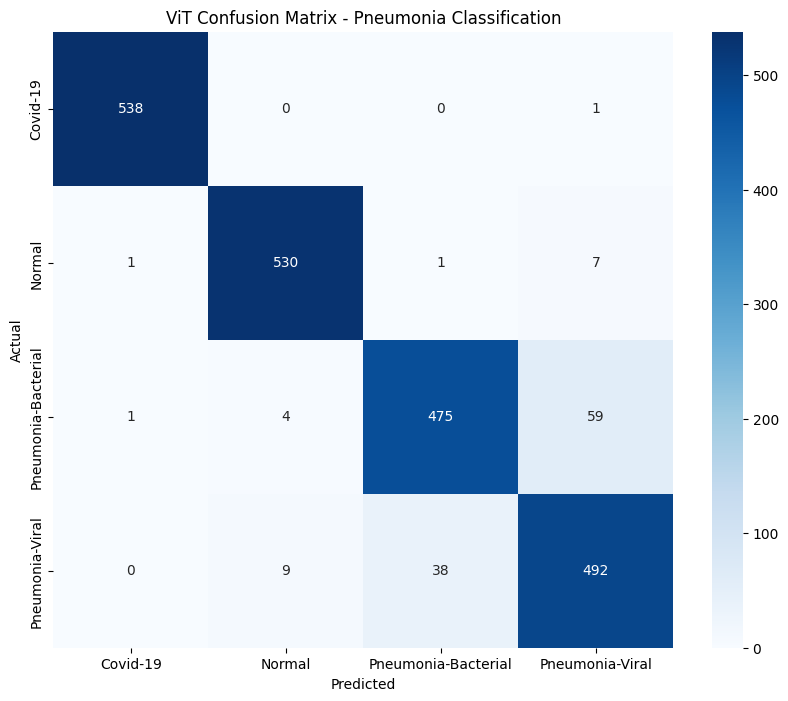


Classification Report:

                     precision    recall  f1-score   support

           Covid-19       1.00      1.00      1.00       539
             Normal       0.98      0.98      0.98       539
Pneumonia-Bacterial       0.92      0.88      0.90       539
    Pneumonia-Viral       0.88      0.91      0.90       539

           accuracy                           0.94      2156
          macro avg       0.94      0.94      0.94      2156
       weighted avg       0.94      0.94      0.94      2156



In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_dataloader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs).logits
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- Metric A: Confusion Matrix ---
class_names = ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ViT Confusion Matrix - Pneumonia Classification')
plt.show()

# --- Metric B: Classification Report ---
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))